In [68]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import math

plt.style.use('seaborn-v0_8') # I personally prefer seaborn for the graph style, but you may choose whichever you want.
params = {"ytick.color" : "black",
          "xtick.color" : "black",
          "axes.labelcolor" : "black",
          "axes.edgecolor" : "black",
          "text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"]}
plt.rcParams.update(params)

output_dir = "/Users/russell/projects/stencil_research/fft_bench/plots"

In [69]:
warmup_iter = 2

results_dirs = [
    "/Users/russell/projects/stencil_research/fft_bench/results/expanse_4",
    "/Users/russell/projects/stencil_research/fft_bench/results/expanse_mkl_threads"
]

plan_data = {
    "Estimate": {},
    "Measure": {},
    "MKL_OUT_OF_PLACE": {},
}

def load_results_file(path):
    with open(json_path, 'r') as json_file:
        data = json.load(json_file)
        plan_type = data["plan_type"]
        time = np.average(data["timings"][warmup_iter:])
        std = np.std(data["timings"][warmup_iter:])
        plan_size = data["plan_size"]
        threads = data["threads"]
        if not plan_size in plan_data[plan_type]:
             plan_data[plan_type][plan_size] = {}
        plan_data[plan_type][plan_size][threads] = { "time": time, "std": std }
        
for results_dir in results_dirs:  
    for file in sorted(os.listdir(results_dir)):
        json_path = f"{results_dir}/{file}"
        load_results_file(json_path)

In [70]:
plot_data = {
    16777216: {
        "FFTW - Estimate": {},
        "FFTW - Measure": {},
        "MKL": {},
    },
    8388608: {
        "FFTW - Estimate": {},
        "FFTW - Measure": {},
        "MKL": {},
    },
    4194304: {
        "FFTW - Estimate": {},
        "FFTW - Measure": {},
        "MKL": {},
    },
}
for plan_type in plan_data.keys():
    for plan_size in plan_data[plan_type]:
        name = "FFTW - Estimate"
        if plan_type == "Measure":
            name = "FFTW - Measure"
        elif plan_type == "MKL_OUT_OF_PLACE":
            name = "MKL"
        threads = sorted(plan_data[plan_type][plan_size].keys())
        times = [plan_data[plan_type][plan_size][thread]["time"] for thread in threads]
        stds = [plan_data[plan_type][plan_size][thread]["std"] for thread in threads]
        plot_data[plan_size][name]["threads"] = threads
        plot_data[plan_size][name]["times"] = times
        plot_data[plan_size][name]["stds"] = stds

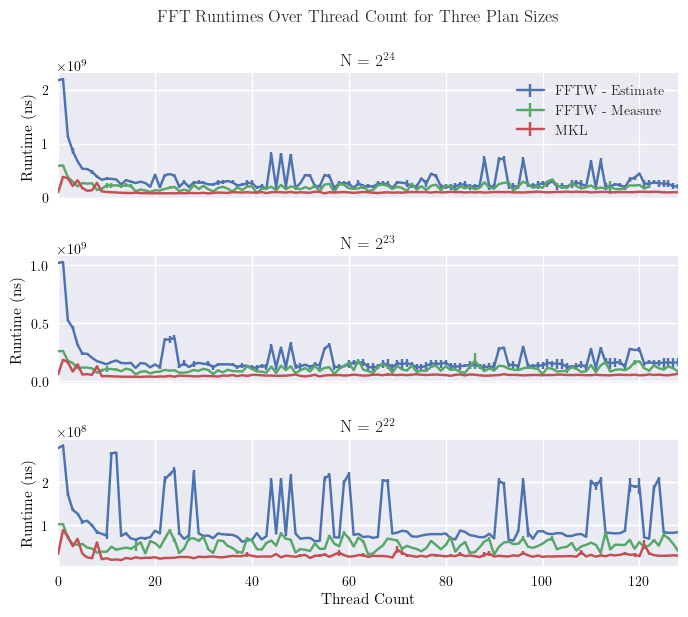

In [71]:
width = 8
height_ratio = 0.8
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 3
n_cols = 1
width_ratios = [1.0]
height_ratios = [1.0, 1.0, 1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.45,
    hspace = 0.45,
)
ax_1 = fig.add_subplot(gs1[0, 0])
ax_2 = fig.add_subplot(gs1[1, 0])
ax_3 = fig.add_subplot(gs1[2, 0])

xlo = 0
xhi = 128

plan_size = 16777216
for name in plot_data[plan_size].keys():
    ax_1.errorbar(
        plot_data[plan_size][name]["threads"], 
        plot_data[plan_size][name]["times"], 
        yerr=plot_data[plan_size][name]["stds"], 
        label=name
    )
ax_1.legend()
ax_1.set_ylabel("Runtime (ns)")
ax_1.set_xticklabels([])
ax_1.set_title("N = $2^{24}$")
ax_1.set_xlim(xlo, xhi)
#ax_1.set_xlabel("Thread Count")

plan_size = 8388608
for name in plot_data[plan_size].keys():
    ax_2.errorbar(
        plot_data[plan_size][name]["threads"], 
        plot_data[plan_size][name]["times"], 
        yerr=plot_data[plan_size][name]["stds"], 
        label=name
    )
#ax_2.legend()
ax_2.set_ylabel("Runtime (ns)")
ax_2.set_xticklabels([])
ax_2.set_title("N = $2^{23}$")
ax_2.set_xlim(xlo, xhi)
#ax_2.set_xlabel("Thread Count")

plan_size = 4194304
for name in plot_data[plan_size].keys():
    ax_3.errorbar(
        plot_data[plan_size][name]["threads"], 
        plot_data[plan_size][name]["times"], 
        yerr=plot_data[plan_size][name]["stds"], 
        label=name
    )
#ax_3.legend()
ax_3.set_ylabel("Runtime (ns)")
ax_3.set_xlabel("Thread Count")
ax_3.set_title("N = $2^{22}$")
ax_3.set_xlim(xlo, xhi)

fig.suptitle("FFT Runtimes Over Thread Count for Three Plan Sizes ")
plt.savefig(f"{output_dir}/thread_scaling.pdf")

In [67]:
for i in range(10, 20):
    p = 2**i
    print(f"{i} -> {p}")

10 -> 1024
11 -> 2048
12 -> 4096
13 -> 8192
14 -> 16384
15 -> 32768
16 -> 65536
17 -> 131072
18 -> 262144
19 -> 524288
